# Gen-axis SR comparison figures

Per-**generation** comparison plots for the symbolic-regression evolution runs.
All the plotting machinery lives in `gen_axis_plots.py`; this notebook only holds
the per-figure *commands* (which run ids, which panels, which title) so each
figure can be browsed / tweaked / re-run on its own.

- `gp.load_method(api, widx, [ids...], tag)` -> per-seed entries for one method
- `gp.render(methods, out_path, suptitle, panels=...)` -> the panel grid
  - `methods` = list of `(name, runs, color, marker)`
  - `panels`  = `gp.PANELS_COMPARISON` (multi-method, bar decomp) or
    `gp.PANELS_SINGLE` (one run: best-current + re-evals + table decomp)

Re-run the setup cell after editing `gen_axis_plots.py` (autoreload picks it up).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import gen_axis_plots as gp

api = gp.get_api()
wandb_index = gp.build_wandb_index()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/sca63/.netrc.


## Quick plot (scratch)

Paste run ids, pick the axis, get a saved PNG. Everything below this is the
curated per-figure record; this cell is the throwaway one.

`gp.quick_plot(ids, name, gen_axis=True/False)`
- `ids`: `[883427, 883429]` for one group, or `{"n1": [...], "n3": [...]}` to compare
- `gen_axis=True`  -> `plots/gen_axis_n1_vs_n3/gen_axis_<name>.png` (per generation)
- `gen_axis=False` -> `plots/eval_axis_comparison/eval_axis_comparison_<name>.png` (per total eval)
- optional `title=...`, and `panels=gp.PANELS_SINGLE/PANELS_COMPARISON` (gen axis only)

n1s0: 31 gen points, 31 val points, max cum_evals=304
n1: loaded 1/1 seeds
n3s0: 26 gen points, 26 val points, max cum_evals=762
n3: loaded 1/1 seeds
u-n1s0: 28 gen points, 28 val points, max cum_evals=555
u-n1: loaded 1/1 seeds
saved: /home/sca63/meta_sr/plots/gen_axis_n1_vs_n3/gen_axis_scratch.png


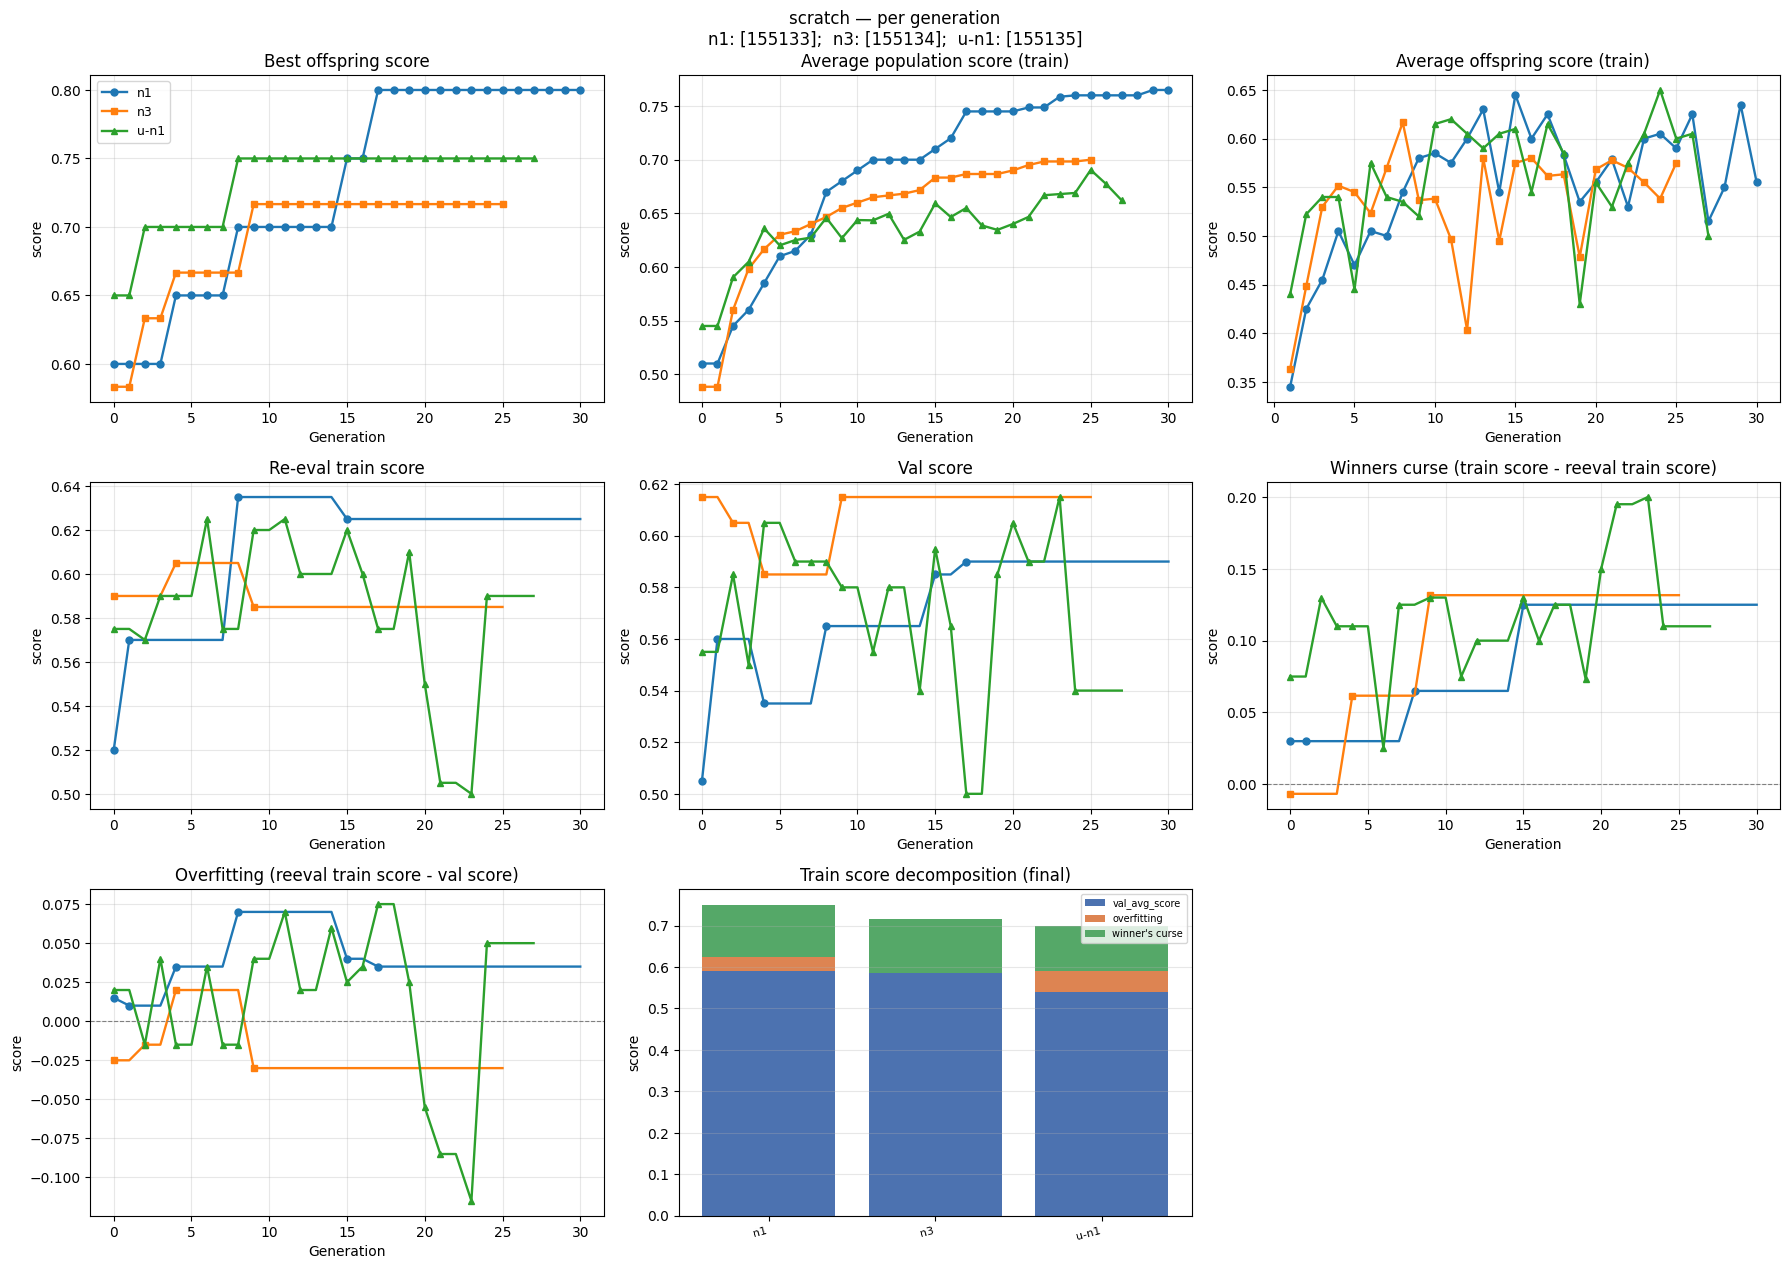

In [4]:
IDS = {"n1": [155133], "n3": [155134], "u-n1": [155135]}

gp.quick_plot(IDS, "scratch", gen_axis=True)
plt.show()

## Run ids

Edit these lists to swap seeds in/out. Each is one method (a set of seeds).
`reeval=none`, `offspring=20` throughout unless noted.

In [ ]:
N1_NONE  = [883427, 883429, 883431, 883433, 883435]  # nn_n1o20  seeds 0-4 (7/16 continuation, to gen 30)
N3_NONE  = [883428, 883430, 883432, 883434, 883436]  # nn_n3o20  seeds 0-4 (7/16 continuation, to gen 30)
N10_NONE = [568245, 568246]                          # nn_n10o20 seeds 0-1 (older, reeval=none)
# smart-reeval n1: offspring 5 + smart reeval, B=20 evals/gen (budget-matched to n1o20)
SMART_N1 = [825767, 825771, 825775, 825779, 825783]  # sm_n1o5b20 seeds 0-4
BEST_RUN = 538190

## n1 vs n3 vs n10 (all reeval=none, offspring=20)

Same #offspring/gen for all; per generation isolates the effect of averaging each
offspring over more seeds (n3 pays 3x, n10 pays 10x eval cost -- factored out here).

In [ ]:
n1  = gp.load_method(api, wandb_index, N1_NONE,  "n1")
n3  = gp.load_method(api, wandb_index, N3_NONE,  "n3")
n10 = gp.load_method(api, wandb_index, N10_NONE, "n10")

gp.render(
    [("n1 (n_runs 1)",  n1,  gp.COLOR(0), "o"),
     ("n3 (n_runs 3)",  n3,  gp.COLOR(3), "s"),
     ("n10 (n_runs 10)", n10, gp.COLOR(2), "^")],
    gp.OUTDIR / "gen_axis_n1_vs_n3.png",
    "n1 vs n3 vs n10 (all reeval=none, offspring=20) — per generation\n"
    "n1/n3 = 7/16 continuation runs (to gen 30); n3/n10 pay 3x/10x eval cost (factored out here)",
    panels=gp.PANELS_COMPARISON,
)
plt.show()

## smart-n1 vs n3

smart n1 spends the SAME 20 evals/gen as n1o20 but on 5 offspring + smart reeval;
n3 spends 60 evals/gen (20 offspring x 3 seeds). If smart n1 tracks n3 here, smart
reeval matches brute-force averaging far more cheaply.

In [ ]:
smart_n1 = gp.load_method(api, wandb_index, SMART_N1, "smart n1")

gp.render(
    [("smart n1 (o5, B=20)",      smart_n1, gp.COLOR(2), "^"),
     ("n3 (n_runs 3, o20, B=60)", n3,       gp.COLOR(3), "s")],
    gp.OUTDIR / "gen_axis_smart_n1_vs_n3.png",
    "smart-n1 vs n3 — per generation\n"
    "smart n1: offspring 5 + smart reeval, 20 evals/gen;  "
    "n3: offspring 20 x 3 seeds, 60 evals/gen",
    panels=gp.PANELS_COMPARISON,
)
plt.show()

## Single best run (538190)

One run, no comparison. Uses `PANELS_SINGLE`: "best score (current posteriors)"
(can drop when a re-eval lowers the top candidate), a re-evals-per-gen panel, and
the train-score decomposition as a table.

In [ ]:
best = gp.load_method(api, wandb_index, [BEST_RUN], "best")

gp.render(
    [(f"run {BEST_RUN}", best, gp.COLOR(0), "o")],
    gp.OUTDIR / "gen_axis_best_run.png",
    f"Best run ({BEST_RUN}) — per generation",
    panels=gp.PANELS_SINGLE,
)
plt.show()